### PneumoniaClassifierDatasetPreprocessing
###### ________________________________________________________________________________________________________________________
#### In this notebook the kaggle dataset is downloaded and pre-processed into a new dataset usable for Neural network training:
##### 1. Make sure the kaggle dataset is downloaded, if not download the dataset and get organised pictures dictionary
##### 2. Pre-process the dataset and store the preprocessed images (numpy.ndarray) locally.
###### 2.1.   Remove previous processed dataset if existing
###### 2.2.   Combine validation and training sets
###### 2.3.   Create new validation/training split with 1:10 ratio
###### 2.4.   Preprocess all images
###### 2.5.   Save processed images to local folders
##### 3. Read the created images into the notebook, and generate a set of x_train and y_label data for each train, val and test split. this part is to be called and re-used when training the neural network
##### 4. Visually inspect the generated labeled data

In [ ]:
# If kagglehub is not installed, make sure to install it
!pip install kagglehub

In [ ]:
# Install open cv if not installed
!pip install opencv-python

In [17]:
# Dependencies
import random
import cv2
import matplotlib.pyplot as plt

### 1. Make sure the kaggle dataset is downloaded

In [2]:
# Import dependencies
import random
import matplotlib.pyplot as plt
from PIL import Image
from PIL import ImageFile
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for showing plots
import cv2 # For images reading
from sklearn.model_selection import train_test_split

In [7]:
# Import PneumoniaDatasetDoenloader.py 
# This file contains functions that download kaggle dataset and read images from downloaded folders
# The Dataset is download path depends on the operating system, and is not downloaded on the repository local path
import src.PneumoniaDatasetDownloaderService

In [13]:
# Get the kaggle dataset by calling "load_dataset_structure" function
# This function checks if kaggle dataset is already downloaded, Otherwise it downloads the kaggle dataset
# And sorts the images by train/test/val => NORMAL/PNEUMONIA
# Returning a dictionary: {
#     "Test_Normal": [...],
#     "Train_Normal": [...],
#     "Val_Normal": [...],
#     "Test_Pneumonia": [...],
#     "Train_Pneumonia": [...],
#     "Val_Pneumonia": [...]
# }
# The Dataset is download path depends on the operating system, and is not downloaded on the repository local path
dataset = src.PneumoniaDatasetDownloaderService.load_Pneumonia_X_Ray_dataset()

Test_Normal = dataset["Test_Normal"]
Train_Normal = dataset["Train_Normal"]
Val_Normal = dataset["Val_Normal"]
Test_Pneumonia = dataset["Test_Pneumonia"]
Train_Pneumonia = dataset["Train_Pneumonia"]
Val_Pneumonia = dataset["Val_Pneumonia"]

Dataset already exists.


### 2. Pre-process the dataset and store the preprocessed images (numpy.ndarray) locally.

In [16]:
import src.ImagesPreprocessorService

#### ImagesPreprocessorService class includes some methods (services) that are used in images preprocessing:
#### 1. preprocess_image(image_path):
#####    Load and preprocess a single image.
#####     Preprocessing steps:
#####     1. Load image
#####     2. Perform center crop to obtain square image
#####     3. Resize image to fixed dimensions
#####     4. Normalize pixel values to range [0, 1]
#### 2. process_dataset(dataset):
#####    Rebuild and preprocess the dataset.
#####    1. Remove previous processed dataset if it exists
#####    2. Combine old validation and testing sets
#####    3. Create new validation/testing split
#####    4. Preprocess all images
#####    5. Save processed images to local folders
#### 3. load_processed_dataset(processed_root="processed_data"):
#####    Loads the processed dataset.
#### 4. get_labeled_datasets(training_dataset, validation_dataset, testing_dataset):
#####    Convert training, validation, and testing datasets
#####    into image paths and numeric labels.

In [19]:
src.ImagesPreprocessorService.process_dataset(dataset)

Processing: train/NORMAL
Processing: train/PNEUMONIA
Processing: val/NORMAL
Processing: val/PNEUMONIA
Processing: test/NORMAL
Processing: test/PNEUMONIA

Dataset preprocessing completed.


###  3.Read the created images into the notebook, and generate a set of x_train and y_label data for each train, val and test split. 
#### This part is to be called and re-used when training the neural network.

In [24]:
( complete_dataset, training_dataset, validation_dataset, testing_dataset) = src.ImagesPreprocessorService.load_processed_dataset()

print("Processed images by folder:")
print("Training:")
print(f"Normal: {len(training_dataset['Normal'])}" )
print(f"Pneumonia: {len(training_dataset['Pneumonia'])}" )
print("Validation:")
print(f"Normal: {len(validation_dataset['Normal'])}")
print(f"Pneumonia: {len(validation_dataset['Pneumonia'])}")
print("Testing:")
print(f"Normal: {len(testing_dataset['Normal'])}")
print(f"Pneumonia: {len(testing_dataset['Pneumonia'])}")

Processed images by folder:
Training:
Normal: 1214
Pneumonia: 3494
Validation:
Normal: 135
Pneumonia: 389
Testing:
Normal: 234
Pneumonia: 390


In [26]:
(X_train, y_train, X_val, y_val, X_test, y_test) = src.ImagesPreprocessorService.get_labeled_datasets(training_dataset, validation_dataset, testing_dataset)

In [28]:
print("Training Images:", len(X_train))
print("Training Labels:", len(y_train))
print()
print("Validation Images:", len(X_val))
print("Validation Labels:", len(y_val))
print()
print("Testing Images:", len(X_test))
print("Testing Labels:", len(y_test))

Training Images: 4708
Training Labels: 4708

Validation Images: 524
Validation Labels: 524

Testing Images: 624
Testing Labels: 624


### 4. Visualise some examples from the preprocessed dataset

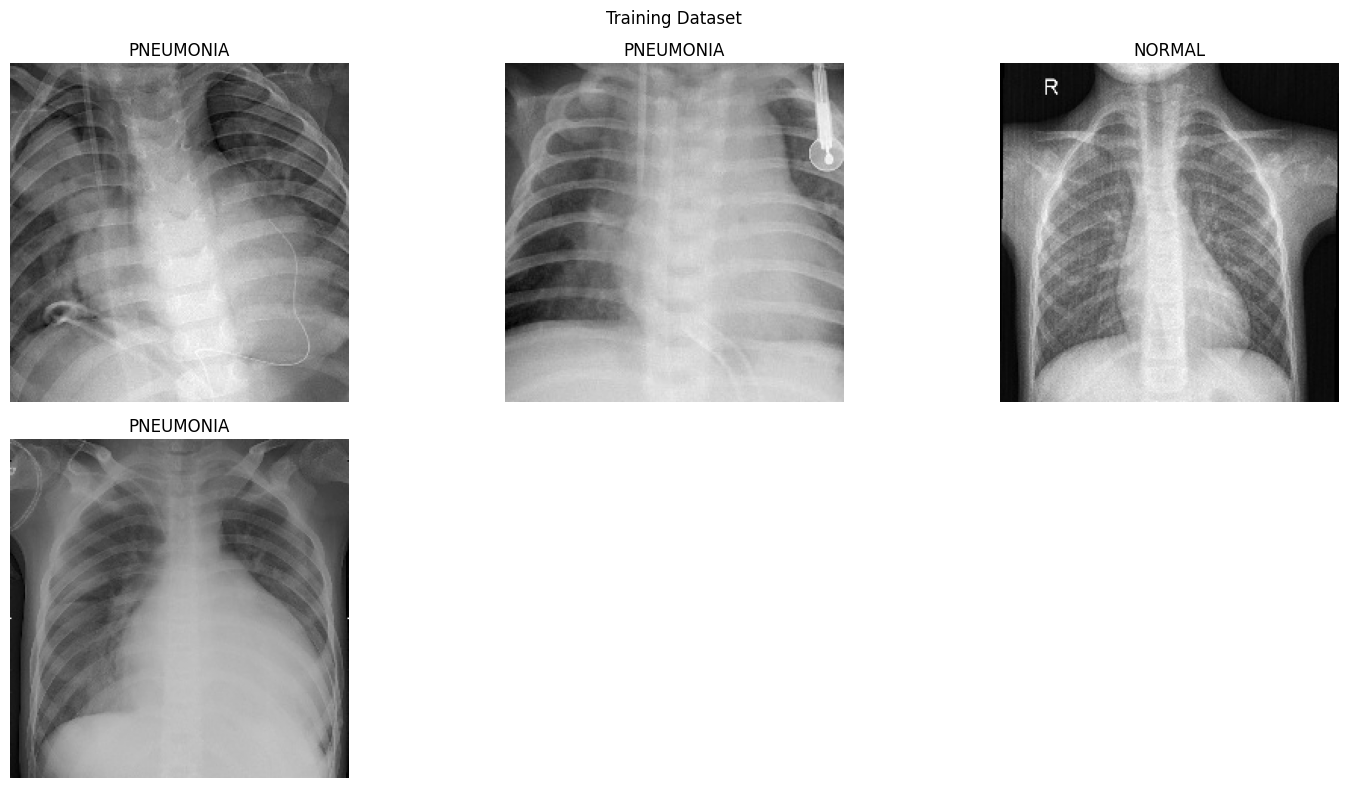

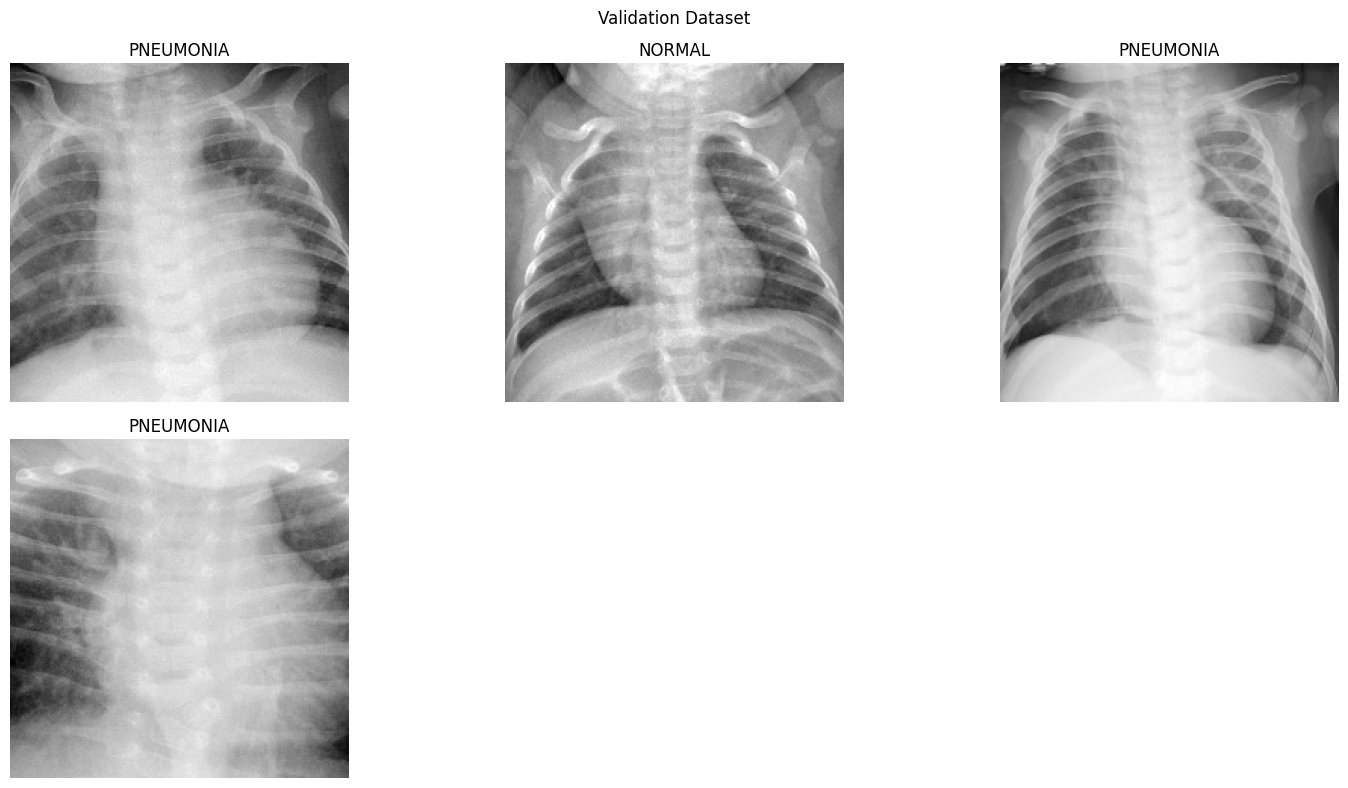

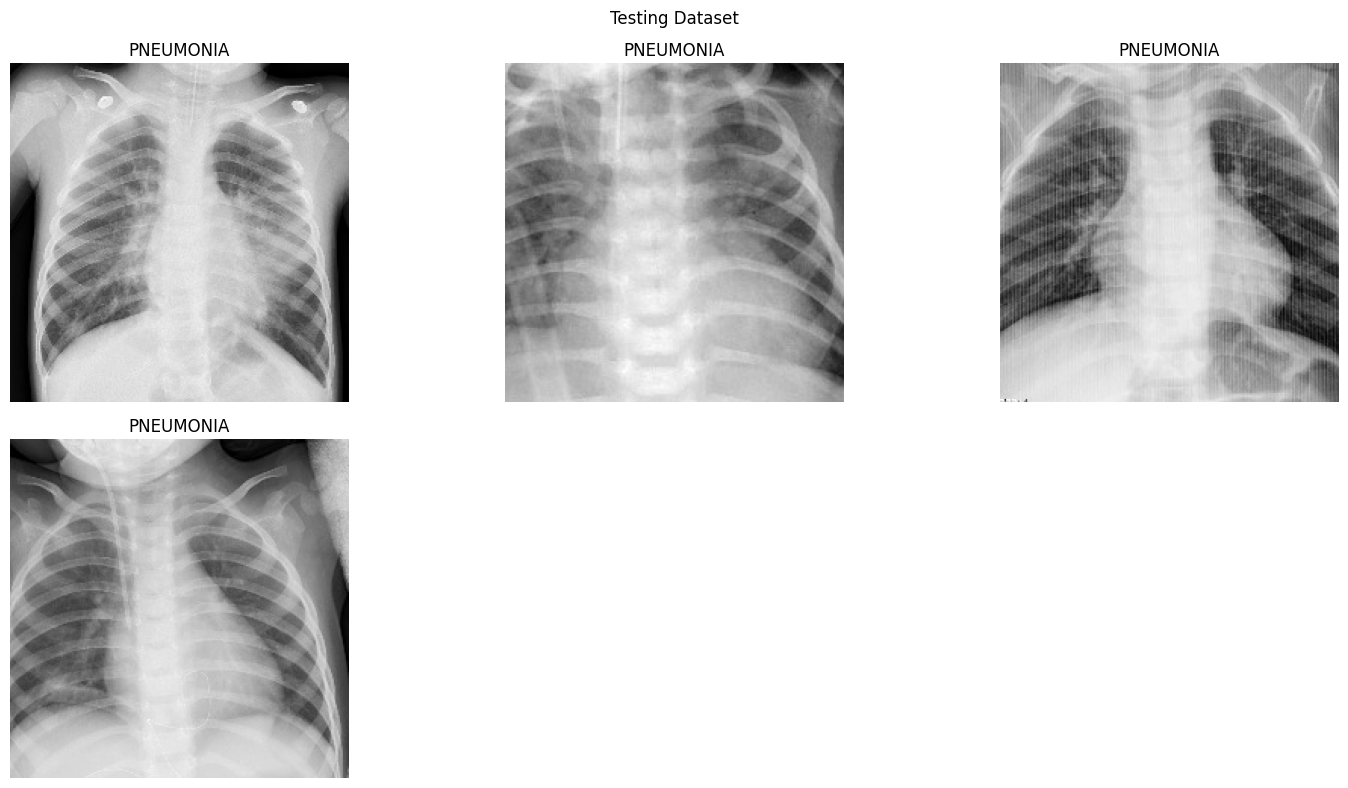

In [25]:
# Show random images from each set as a visual inspection
def show_images(image_paths, labels, title, num_images=4):
    """
    Display random images from a dataset split.
    Labels:
        0 -> Normal
        1 -> Pneumonia
    Parameters:
        image_paths (list):
            List of image file paths.
        labels (list):
            Corresponding numeric labels.
        title (str):
            Figure title.
        num_images (int):
            Number of random images to display.
    """
    # Combine paths and labels
    data = list(zip(image_paths, labels))

    # Select random samples
    samples = random.sample(data, min(num_images, len(data)))

    plt.figure(figsize=(15, 8))

    for index, (image_path, label) in enumerate(samples):
        image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
        label_name = ("NORMAL" if label == 0 else "PNEUMONIA")

        plt.subplot(2, 3, index + 1)
        plt.imshow(image, cmap="gray")
        plt.title(label_name)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_images(X_train, y_train, title="Training Dataset")
show_images(X_val, y_val, title="Validation Dataset")
show_images(X_test, y_test, title="Testing Dataset")